# Lab 7: Great British Bake Off (A/B Test)

Welcome to Data 8 Lab 7! This week's lab will focus on A/B Testing using data from the ever-popular British television show, [*The Great British Bakeoff*](https://en.wikipedia.org/wiki/The_Great_British_Bake_Off).


First, set up the notebook by running the cell below.

In [7]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', (FutureWarning, np.VisibleDeprecationWarning))


## 1. A/B Testing

A/B testing is a form of hypothesis testing that allows you to make comparisons between two distributions. We may also refer to an A/B test as a permutation test.

You'll almost never be explicitly asked to perform an A/B test. Make sure you can identify situations where the test is appropriate and know how to correctly implement each step. Oftentimes, we use an A/B test to determine whether or not two samples came from the same underlying distribution.

**Question 1.1.** The following statements are the steps of an A/B hypothesis test presented in a *random order*:

1. Choose a test statistic (typically the difference in means between two categories)

2. Shuffle the labels of the original sample, find your simulated test statistic, and repeat many times

3. Find the value of the observed test statistic

4. Calculate the p-value based off your observed and simulated test statistics

5. Define a null and alternate model

6. Use the p-value and p-value cutoff to draw a conclusion about the null hypothesis

Assign `ab_test_order` to an array of integers that contains the correct order of an A/B test, where the first item of the array is the first step of an A/B test and the last item of the array is the last step of an A/B test.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [8]:
ab_test_order = [5, 1, 3, 2, 4, 6]

END SOLUTION

**Question 1.2.** If the null hypothesis of an A/B test is correct, should the order of labels affect the differences in means between each group? Why do we shuffle labels in an A/B test? If you are in a lab section, confirm your answer with a neighbor or staff member before moving on. 


Type your solution in the following cell. Be sure to include comments explaining your code.

No, because the two groups are assumed to be identical no matter the label under the null. We shuffle the labels instead of randomly choosing one because we need to maintain the sample size for each of the labels, so we can't change the number of samples in each group.

END SOLUTION

## 2. The Great British Bake Off

>"The Great British Bake Off (often abbreviated to Bake Off or GBBO) is a British television baking competition, produced by Love Productions, in which a group of amateur bakers compete against each other in a series of rounds, attempting to impress a group of judges with their baking skills" [Wikipedia](https://en.wikipedia.org/wiki/The_Great_British_Bake_Off)

For every week of the competition, the judges assign one contestant the title "Star Baker". Ultimately, one winner is crowned every season. Using this information, we would like to investigate how winning Star Baker awards affects the odds of winning a season of the show.

**Question 2.1.** We want to know whether winning more Star Baker awards *causes* a change in likelihood of winning the season.  Why is it not sufficient to compare star baker rates for winners and losers?


Type your solution in the following cell. Be sure to include comments explaining your code.

Correlation does not imply causation, it could be due to random chance. We need to assume the null hypothesis that the distritbution is identical no matter if they won or not. We need to see if there is too little chance of randomness causing the observed difference.

END SOLUTION

### Running an Experiment

We are going to run the following hypothesis test to determine the association between winning and number of Star Baker awards. The population we are examining is every contestant from seasons 2 through 11 of GBBO. We are going to use the following null and alternative hypotheses:

**Null hypothesis:** The distribution of Star Baker awards between contestants who won their season and contestants who did not win their season is the same.

**Alternative hypothesis:** Contestants who win their season of the show will win more Star Baker awards on average.

Our alternative hypothesis is related to our suspicion that contestants who win more Star Baker awards are more skilled, so they are more likely to win the season.

**Question 2.2.** Should we use an A/B test to test these hypotheses? If yes, what is our "A" group and what is our "B" group?


Type your solution in the following cell. Be sure to include comments explaining your code.

Yes we should an A/B test here, because we are comparing two groups that should be identical under the null, and we are trying to prove a difference. Group A could be contestants who won their season, B could be contestants who didn't win.

END SOLUTION

Check your answers with your neighbors or a staff member before you move on to the next section.

The `bakers` table below describes the number of star baker awards each contest won and whether or not they won their season (`1` if they won, `0` if they did not win). The data was manually aggregated from Wikipedia for seasons 2-11 of the show. We randomized the order of rows as to not spoil the outcome of the show.

In [10]:
bakers = Table.read_table("star_bakers-1.csv")
bakers.show(3)

star baker awards,won
3,1
0,0
1,0


**Question 2.3.** Create a new table called `means` that contains the mean number of star baker awards for bakers who did not win (`won==0`) and bakers that did win (`won==1`). The table should have the column names `won` and `star baker awards mean`.

Type your solution in the following cell. Be sure to include comments explaining your code.

In [11]:

means = bakers.select("won", "star baker awards").group("won", np.mean)

means

won,star baker awards mean
0,0.651786
1,1.5


END SOLUTION

**Question 2.4.** Visualize the distribution of Star Baker awards for winners and non-winners. You should use the bins we provided.

Hint: You will want to use the group argument of `tbl.hist`. In order to produce several overlayed histograms based on unique values in a given column, we can do something like `tbl.hist(..., group=<col_name>, bins=...)`!


Type your solution in the following cell. Be sure to include comments explaining your code.

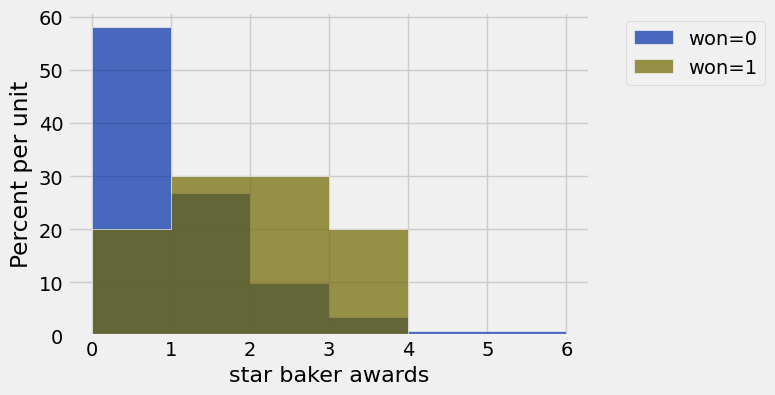

In [16]:
useful_bins = np.arange(0, 7)

bakers.hist("star baker awards", bins=useful_bins, group="won")

END SOLUTION

**Question 2.5.** We want to figure out if there is a difference between the distribution of Star Baker awards between winners and non winners. 

What should the test statistic be? Which values of this test statistic support the null, and which values support the alternative?

If you are in lab, confirm your answer with a neighbor or staff member before moving on.

Hint: You should think about what measures we use to describe a distribution. 


Type your solution in the following cell. Be sure to include comments explaining your code.

We can use the difference of means as the test statistic, a test statistic of winners-losers means being 0 or less than 0 would suport the null, and positive values would support the alternative.

END SOLUTION

**Question 2.6.** Set `observed_difference` to the observed test statistic using the `means` table. 


Type your solution in the following cell. Be sure to include comments explaining your code.

In [19]:
observed_difference = means.column(1).item(1) - means.column(1).item(0)
observed_difference

0.8482142857142857

END SOLUTION

**Question 2.7.** Given a table like `bakers`, a label column `label_col`, and a values column `val_col`, write a function that calculates the appropriate test statistic.

*Hint:* Make sure that you are taking the directionality of our alternative hypothesis into account.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [20]:
def find_test_stat(tbl, label_col, val_col):
    means = tbl.select(label_col, val_col).group(label_col, np.mean)
    return means.column(1).item(1) - means.column(1).item(0)



find_test_stat(bakers, "won", "star baker awards")

0.8482142857142857

END SOLUTION

When we run a simulation for A/B testing, we resample by **shuffling the labels** of the original sample. If the null hypothesis is true and the star baker award distributions are the same, we expect that the difference in mean star baker awards will be not change when `"won"` labels are changed.

**Question 2.8.** Write a function `simulate_and_test_statistic` to compute one trial of our A/B test. Your function should run a simulation and return a test statistic.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [35]:
def simulate_and_test_statistic(tbl, labels_col, values_col):
    shuffled_labels = tbl.sample(with_replacement=False).column(labels_col)
    
    shuffled_tbl = tbl.with_column("Shuffled Label", shuffled_labels)
    
    return find_test_stat(shuffled_tbl, "Shuffled Label", values_col)

simulate_and_test_statistic(bakers, "won", "star baker awards")

-0.2410714285714286

END SOLUTION

**Question 2.9.** Simulate 5000 trials of our A/B test and store the test statistics in an array called `differences`.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [42]:
# This cell might take a couple seconds to run
differences = make_array()

repetitions = 5000

for i in np.arange(repetitions):
    difference = simulate_and_test_statistic(bakers, "won", "star baker awards")
    differences = np.append(differences, difference)

                                                 
differences

array([ 0.08571429, -0.24107143, -0.13214286, ..., -0.35      ,
       -0.35      , -0.56785714])

END SOLUTION

Run the cell below to view a histogram of your simulated test statistics plotted with your observed test statistic.

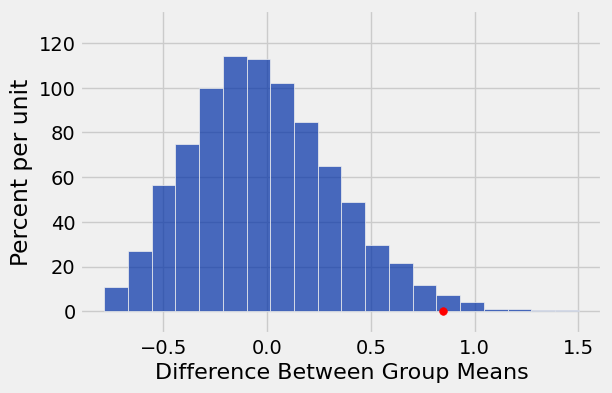

In [43]:
Table().with_column('Difference Between Group Means', differences).hist(bins=20)
plots.scatter(observed_difference, 0, color='red', s=30, zorder=2)
plots.ylim(-0.1, 1.35);

**Question 2.10.** Find the p-value for your test and assign it to `empirical_p`.


Type your solution in the following cell. Be sure to include comments explaining your code.

In [45]:


empirical_p = np.count_nonzero(differences >= observed_difference) / repetitions
empirical_p

0.0166

END SOLUTION

**Question 2.11.** Using a 5% P-value cutoff, draw a conclusion about the null and alternative hypotheses. Describe your findings using simple, non-technical language. What does your analysis tell you about the association between star baker awards and winning? What can you claim about causation from your statistical analysis? Call your GSI or AI over and confirm your answer. 


Type your solution in the following cell. Be sure to include comments explaining your code.

Because the cutoff is higher than the observed empirical p, then we can say that the difference we saw in the original data was more extreme than what could happen simply by chance. This says that the difference cannot only be caused by chance, and must mean that star baker awards cause a higher rate of winning the season. Because we ran a study we can prove causation of the two data points.

END SOLUTION

You're done with lab 7!  